# VSP Flight Sim - VSP Scripted Batch Solver

Readme: 
This code is used in pair with OPENVSP 3.50.5 to generate a rough estimate to the performance of Group 1 Fixed Wing UAV under steady state scenarios. 

# Steps
1. If initial run, do setup.sh to install/update requirements.txt
2. From CAD model, setup simulation config using vspaero_run.py
    - Modifies existing .vspaero file to setup for cfd
3. run_sim.sh (Make sure to launch openvsp first and use the GUI to generate degenGeom!)
    - runs batch sweep and triggers vspaero solver
    - outputs vsp_aero_result.csv in /output
4. Flight_Calc.ipynb extracts vsp_aero_result.csv into custom data processing
    - Runs propulsion trade study

In [530]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "jupyterlab"
import ipywidgets as widgets
from IPython.display import display
import subprocess
import os
from pyxfoil import Xfoil, set_workdir, set_xfoilexe
from pathlib import Path

## Xfoil Airfoil

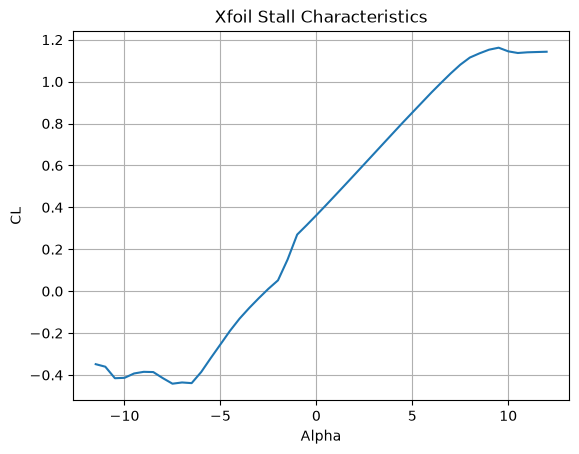

Maximum Lift Coefficient (CL_max): 1.1618
Stall Angle of Attack (alpha_stall): 9.5 degrees


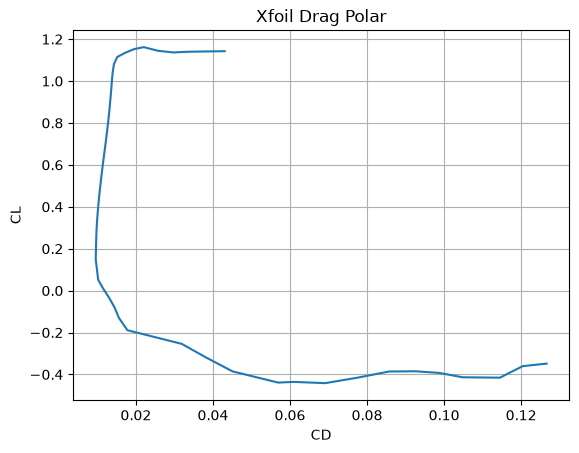

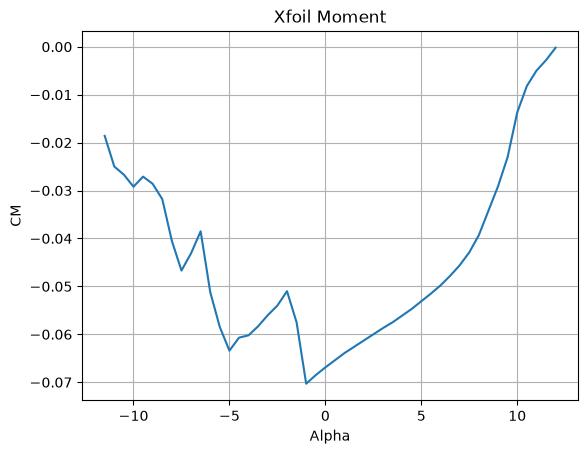

In [ ]:
## Airfoil Stall characteristics from XFOIL
workdir = Path("/Users/erickoo/Downloads/vsp_flight_sim/OpenVSP")
xfoilexe_dir = Path('/opt/homebrew/bin/xfoil')
polar_path = workdir / "e205_Re200k.pol"
airfoil_path = workdir / "e205-selig.dat"
xf = Xfoil("e205-selig")
xf.points_from_dat(str(airfoil_path))
xf.set_ppar(280)

if polar_path.exists():
    polar_path.unlink()

commands = f"""
LOAD {airfoil_path}
E205
PANE
OPER
VISC 200000
MACH 0.05
ITER 200
PACC
{polar_path}

ASEQ -12 12 0.5
PACC
QUIT
"""

result = subprocess.run(
    [xfoilexe_dir],
    input=commands,
    text=True,
    capture_output=True,
    cwd=workdir
)
polar_df = pd.read_csv(
    polar_path,
    sep=r"\s+",
    skiprows=12,
    names=["alpha", "CL", "CD", "CDp", "CM", "Top_Xtr", "Bot_Xtr", "Top_Itr", "Bot_Itr"]
)
polar_df.head()
plt.plot(polar_df["alpha"], polar_df["CL"])
plt.xlabel('Alpha')
plt.ylabel('CL')
plt.title('Xfoil Stall Characteristics')
plt.grid(True)
plt.show()
CL_max = polar_df["CL"].max()
alpha_stall = polar_df.loc[polar_df["CL"].idxmax(), "alpha"]
print(f"Maximum Lift Coefficient (CL_max): {CL_max}")
print(f"Stall Angle of Attack (alpha_stall): {alpha_stall} degrees")

plt.plot(polar_df["CD"], polar_df["CL"])
plt.xlabel('CD')
plt.ylabel('CL')
plt.title('Xfoil Drag Polar')
plt.grid(True)
plt.show()

LD_ratio = polar_df["CL"] / polar_df["CD"]
plt.plot(polar_df["alpha"], LD_ratio)
plt.xlabel('Alpha')
plt.ylabel('LD Ratio')
plt.title('Xfoil Lift-to-Drag Ratio')
plt.grid(True)
plt.show()

plt.plot(polar_df["alpha"], polar_df["CM"])
plt.xlabel('Alpha')
plt.ylabel('CM')
plt.title('Xfoil Moment')
plt.grid(True)
plt.show()

## Trimmed condition

In [532]:
rho = 1.225
mass_kg = 1.8
W = mass_kg * 9.81  

## Trim condition intercept
V_target_kmh = []
for i in range(30,70,1):
    V_target_kmh.append(i)
A = 0.1875

def vel_km_ms_convert(V_kmh):
    return V_kmh/3.6

V_target_ms = vel_km_ms_convert(np.array(V_target_kmh))
CL_required = np.array([2*W/(rho*(V**2)*A) for V in V_target_ms])

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=V_target_ms*3.6,  # Convert back to km/h for the x-axis
        y=CL_required,
        mode='lines+markers',
    )
)
fig.update_layout(
    title='Trimmed Velocity vs CL',
    autosize=False,
    width=800,
    height=560,
    xaxis_title='Velocity [kmh]',
    yaxis_title='CL',
    template='plotly_white',
)
fig.show()

# VSP Solver Result

In [533]:
## parse vsp_aero_results.csv
df = pd.read_csv("output/vsp_aero_results.csv")
cols = df.select_dtypes(include="number").columns.tolist()

x_dd = widgets.Dropdown(
    options=cols,
    value="alpha",
    description = "X:"
)

y_dd = widgets.Dropdown(
    options=cols,
    value="CLtot",
    description="Y:"
)
out = widgets.Output()

def update_plot(x,y):
    with out:
        out.clear_output(wait=True)
        fig = px.line(
            df, 
            x=x,
            y=y,
            color="delta_e_deg",
            #color="xcg",
            #color="Mach",
            markers=True,
            title=f"{y} vs {x} by Elevator"
            #title=f"{y} vs {x} by CG"
            #title=f"{y} vs {x} by vel"
        )
        fig.show()
ui = widgets.HBox([x_dd,y_dd])
display(ui, out)

widgets.interactive_output(
    update_plot,
    {
        "x": x_dd,
        "y": y_dd
    }
)

alpha = df["alpha"].to_numpy()
cm = df["CMytot"].to_numpy()
CLtot = df["CLtot"].to_numpy()
slope_per_deg, intercept = np.polyfit(alpha,cm,1)
slope_per_rad = slope_per_deg * 180/np.pi

#Pitch Stability
print("Cm_alpha per deg:", slope_per_deg)
print("Cm_alpha per rad:", slope_per_rad)
print("Cm(alpha) = %.6f * alpha + %.6f" % (slope_per_deg, intercept))
alpha_trim = -intercept/slope_per_deg
print("Trim alpha [deg]:", alpha_trim)
CL_trim = np.interp(alpha_trim, alpha, CLtot)
print("Trim CL:", CL_trim)

Output()

Cm_alpha per deg: -0.004490059312416664
Cm_alpha per rad: -0.2572614483648872
Cm(alpha) = -0.004490 * alpha + 0.131680
Trim alpha [deg]: 29.32694194787918
Trim CL: 0.514896063151


# Trade Study Result (WIP)

In [534]:
##Test 

W  = np.array([1.8,2.0,2.2,2.4]) #kg
V = np.array([15,20,25,30,35,40]) #km/h

A = 0.15*1 #m^2
rho = 1.225 #kg/m^3
mew = 1.81e-5 #kg/m/s

V_m = V*1000/3600 #m/s

W_grid, V_m_grid = np.meshgrid(W, V_m)

#equations
CL_matrix = 2*W_grid / (V_m_grid**2*A*rho)


fig = go.Figure(data=[go.Surface(
    z=CL_matrix,
    x=W_grid,
    y=V_m_grid,
    colorscale='viridis',
    colorbar=dict(title='$C_L$ Scale', len=0.5)
)])
fig.update_layout(
    title='CL vs W and V',
    autosize=False,
    width=800,
    height=560,
    scene=dict(
        xaxis_title='Weight (kg)',
        yaxis_title='Velocity (m/s)',
        zaxis_title='CL'
    ),
    margin=dict(l=65, r=50, b=65, t=90)
)
fig.show()

print("V_m = ", W)
print("CL = ", CL_matrix)

V_m =  [1.8 2.  2.2 2.4]
CL =  [[1.1284898  1.25387755 1.37926531 1.50465306]
 [0.63477551 0.70530612 0.77583673 0.84636735]
 [0.40625633 0.45139592 0.49653551 0.5416751 ]
 [0.28212245 0.31346939 0.34481633 0.37616327]
 [0.20727364 0.23030404 0.25333444 0.27636485]
 [0.15869388 0.17632653 0.19395918 0.21159184]]
